# Predicción de Turismo por Estado de Residencia (Grupo Verde)

**Objetivo:** construir un modelo de regresión para predecir la cantidad de turistas por país/estado de residencia y tipo de visitante (Dominicano/Extranjero), cumpliendo todas las etapas metodológicas: exploración, preprocesamiento, entrenamiento, evaluación, validación y predicción en nuevos registros.

**Dataset local:** `data/mitur/3. Por estado de residencia.xlsx`

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
RANDOM_STATE = 42


def resolver_data_path() -> Path:
    candidatos = [
        Path("data/mitur/3. Por estado de residencia.xlsx"),
        Path("../data/mitur/3. Por estado de residencia.xlsx"),
    ]
    for candidato in candidatos:
        if candidato.exists():
            return candidato.resolve()
    raise FileNotFoundError("No se encontró el archivo Excel en data/mitur/.")


DATA_PATH = resolver_data_path()
print(f"Usando dataset: {DATA_PATH}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

Usando dataset: /Volumes/Devsu - Extra Space/uasd/datamining/entregables/modelo-predictivo-datos-abiertos/data/mitur/3. Por estado de residencia.xlsx


In [2]:
MESES_ORDEN = [
    "enero", "febrero", "marzo", "abril", "mayo", "junio",
    "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre"
]
MAPA_MESES = {mes: idx + 1 for idx, mes in enumerate(MESES_ORDEN)}
MAPA_MESES_INV = {v: k for k, v in MAPA_MESES.items()}


def cargar_turismo_por_estado(path: Path) -> pd.DataFrame:
    # Lee y transforma las hojas anuales en un solo dataset largo.
    excel = pd.ExcelFile(path)
    hojas = [h for h in excel.sheet_names if h.startswith("Entradas estado residencia")]
    bloques = []

    for hoja in sorted(hojas):
        anio = int(hoja.rsplit(" ", 1)[-1])
        raw = pd.read_excel(path, sheet_name=hoja, skiprows=11)
        raw = raw.rename(columns={raw.columns[0]: "Pais", raw.columns[1]: "Estado"})

        raw["Pais"] = raw["Pais"].ffill().astype(str).str.strip()
        raw["Estado"] = raw["Estado"].astype(str).str.strip()

        columnas_dom = [m for m in MESES_ORDEN if m in raw.columns]
        columnas_ext = [f"{m}.1" for m in MESES_ORDEN if f"{m}.1" in raw.columns]

        dom = raw[["Pais", "Estado", *columnas_dom]].copy()
        dom["Tipo_Visitante"] = "Dominicano"
        dom = dom.melt(
            id_vars=["Pais", "Estado", "Tipo_Visitante"],
            var_name="Mes",
            value_name="Turistas",
        )

        ext = raw[["Pais", "Estado", *columnas_ext]].copy()
        ext = ext.rename(columns={f"{m}.1": m for m in MESES_ORDEN})
        ext["Tipo_Visitante"] = "Extranjero"
        ext = ext.melt(
            id_vars=["Pais", "Estado", "Tipo_Visitante"],
            var_name="Mes",
            value_name="Turistas",
        )

        anual = pd.concat([dom, ext], ignore_index=True)
        anual["Anio"] = anio
        bloques.append(anual)

    df = pd.concat(bloques, ignore_index=True)
    df["Mes"] = df["Mes"].astype(str).str.lower().str.strip()
    df["Mes_Num"] = df["Mes"].map(MAPA_MESES)
    df["Turistas"] = pd.to_numeric(df["Turistas"], errors="coerce")

    df = df.dropna(subset=["Estado", "Mes_Num"])
    df = df[df["Estado"].str.lower() != "nan"].copy()

    df["Fecha"] = pd.to_datetime(
        {"year": df["Anio"], "month": df["Mes_Num"], "day": 1},
        errors="coerce",
    )
    df = df.dropna(subset=["Fecha"]).reset_index(drop=True)
    return df


df_raw = cargar_turismo_por_estado(DATA_PATH)
print("Forma del dataset consolidado:", df_raw.shape)
print("Años disponibles:", sorted(df_raw["Anio"].unique()))
df_raw.head()

Forma del dataset consolidado: (18120, 8)
Años disponibles: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


,Pais,Estado,Tipo_Visitante,Mes,Turistas,Anio,Mes_Num,Fecha
0,Estados Unidos,New York,Dominicano,enero,34206.0,2022,1,2022-01-01
1,Estados Unidos,Florida,Dominicano,enero,8620.0,2022,1,2022-01-01
2,Estados Unidos,New Jersey,Dominicano,enero,14316.0,2022,1,2022-01-01
3,Canadá,Ontario,Dominicano,enero,277.0,2022,1,2022-01-01
4,Canadá,Quebec,Dominicano,enero,232.0,2022,1,2022-01-01


## 1) Exploración del Dataset (EDA)

In [3]:
print("Tipos de datos:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nValores faltantes:")
faltantes = df_raw.isna().sum().to_frame("nulos")
faltantes["porcentaje"] = (faltantes["nulos"] / len(df_raw) * 100).round(2)
display(faltantes)

print("\nEstadísticas descriptivas numéricas:")
display(df_raw[["Turistas", "Mes_Num", "Anio"]].describe().T)

print("\nEstadísticas descriptivas categóricas:")
display(df_raw[["Pais", "Estado", "Tipo_Visitante", "Mes"]].describe().T)

Tipos de datos:


,dtype
Pais,str
Estado,str
Tipo_Visitante,str
Mes,str
Turistas,float64
Anio,int64
Mes_Num,int64
Fecha,datetime64[us]



Valores faltantes:


,nulos,porcentaje
Pais,0,0.0
Estado,0,0.0
Tipo_Visitante,0,0.0
Mes,0,0.0
Turistas,3442,19.0
Anio,0,0.0
Mes_Num,0,0.0
Fecha,0,0.0



Estadísticas descriptivas numéricas:


,count,mean,std,min,25%,50%,75%,max
Turistas,14678.0,2334.719717,7570.517207,1.0,62.00,467.0,1360.75,100980.0
Mes_Num,18120.0,6.500000,3.452148,1.0,3.75,6.5,9.25,12.0
Anio,18120.0,2024.000000,1.414253,2022.0,2023.00,2024.0,2025.00,2026.0



Estadísticas descriptivas categóricas:


,count,unique,top,freq
Pais,18120,40,Estados Unidos,4992
Estado,18120,189,Not Applicable,216
Tipo_Visitante,18120,2,Dominicano,9060
Mes,18120,12,enero,1510


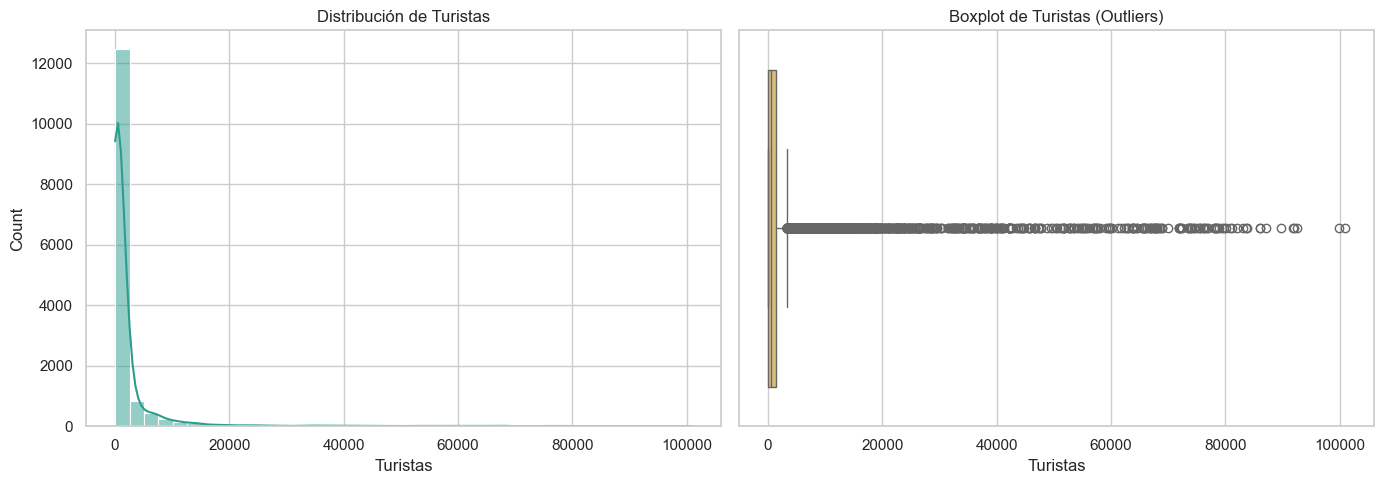

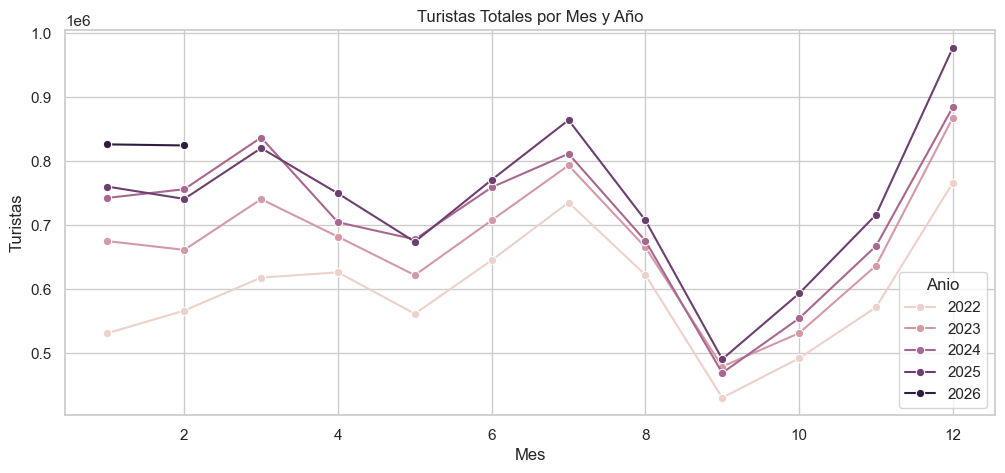

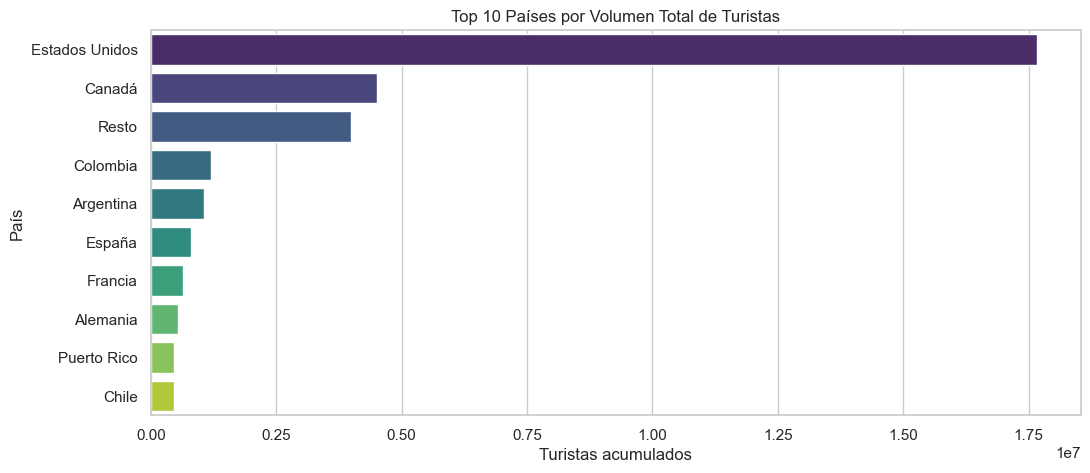

In [4]:
df_eda = df_raw.dropna(subset=["Turistas"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_eda["Turistas"], bins=40, kde=True, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Distribución de Turistas")
axes[0].set_xlabel("Turistas")

sns.boxplot(x=df_eda["Turistas"], ax=axes[1], color="#e9c46a")
axes[1].set_title("Boxplot de Turistas (Outliers)")
axes[1].set_xlabel("Turistas")
plt.tight_layout()
plt.show()

mensual = (
    df_eda.groupby(["Anio", "Mes_Num"], as_index=False)["Turistas"]
    .sum()
    .sort_values(["Anio", "Mes_Num"])
)
plt.figure(figsize=(12, 5))
sns.lineplot(data=mensual, x="Mes_Num", y="Turistas", hue="Anio", marker="o")
plt.title("Turistas Totales por Mes y Año")
plt.xlabel("Mes")
plt.ylabel("Turistas")
plt.show()

top_paises = (
    df_eda.groupby("Pais", as_index=False)["Turistas"].sum()
    .sort_values("Turistas", ascending=False)
    .head(10)
)
plt.figure(figsize=(12, 5))
sns.barplot(data=top_paises, x="Turistas", y="Pais", palette="viridis")
plt.title("Top 10 Países por Volumen Total de Turistas")
plt.xlabel("Turistas acumulados")
plt.ylabel("País")
plt.show()

## 2) Preprocesamiento

In [5]:
# Calidad de datos: outliers por IQR (se detectan, no se eliminan masivamente)
q1 = df_eda["Turistas"].quantile(0.25)
q3 = df_eda["Turistas"].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
outliers = ((df_eda["Turistas"] < limite_inferior) | (df_eda["Turistas"] > limite_superior)).sum()

print(f"Q1={q1:,.2f} | Q3={q3:,.2f} | IQR={iqr:,.2f}")
print(f"Outliers detectados por IQR: {outliers:,} ({outliers/len(df_eda)*100:.2f}% del total con Turistas no nulo)")

# Base de modelado: se eliminan nulos de target y ceros (meses no observados en 2026)
df_model = df_eda[df_eda["Turistas"] > 0].copy()
df_model = df_model.sort_values(["Pais", "Estado", "Tipo_Visitante", "Fecha"])

# Ingeniería de características de rezago
grupo = ["Pais", "Estado", "Tipo_Visitante"]
df_model["lag_1"] = df_model.groupby(grupo)["Turistas"].shift(1)
df_model["lag_12"] = df_model.groupby(grupo)["Turistas"].shift(12)
df_model["rolling_3_mean"] = (
    df_model.groupby(grupo)["Turistas"]
    .transform(lambda s: s.shift(1).rolling(window=3, min_periods=1).mean())
)

df_model = df_model.dropna(subset=["lag_1", "lag_12", "rolling_3_mean"]).copy()
print("Registros listos para modelado:", df_model.shape)

FEATURES = [
    "Pais", "Estado", "Tipo_Visitante",
    "Mes_Num", "Anio", "lag_1", "lag_12", "rolling_3_mean"
]
TARGET = "Turistas"

Q1=62.00 | Q3=1,360.75 | IQR=1,298.75
Outliers detectados por IQR: 1,829 (12.46% del total con Turistas no nulo)
Registros listos para modelado: (10400, 11)


In [6]:
# Split temporal: entrenar con años anteriores y probar en el año más reciente
ultimo_anio = int(df_model["Anio"].max())
train_df = df_model[df_model["Anio"] < ultimo_anio].copy()
test_df = df_model[df_model["Anio"] == ultimo_anio].copy()

if test_df.empty:
    raise ValueError("No hay registros en el último año para usar como test.")

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print(f"Año de test: {ultimo_anio}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Año de test: 2026
Train: (9865, 8) | Test: (535, 8)


## 3) Entrenamiento de Modelos

In [7]:
numeric_features = ["Mes_Num", "Anio", "lag_1", "lag_12", "rolling_3_mean"]
categorical_features = ["Pais", "Estado", "Tipo_Visitante"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

modelos = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=250,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
    ),
}

pipelines_entrenados = {}
resultados = []

for nombre, modelo in modelos.items():
    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", modelo),
        ]
    )
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    resultados.append({
        "Modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    })
    pipelines_entrenados[nombre] = pipe

df_resultados = pd.DataFrame(resultados).sort_values("RMSE").reset_index(drop=True)
display(df_resultados)

mejor_modelo_nombre = df_resultados.iloc[0]["Modelo"]
mejor_modelo = pipelines_entrenados[mejor_modelo_nombre]
print(f"Mejor modelo en test (por RMSE): {mejor_modelo_nombre}")

,Modelo,MAE,RMSE,R2
0,Ridge,407.429256,729.840344,0.994161
1,Linear Regression,407.618337,730.177084,0.994156
2,Random Forest Regressor,263.843910,811.864507,0.992775
3,Gradient Boosting Regressor,296.638788,867.052038,0.991759


Mejor modelo en test (por RMSE): Ridge


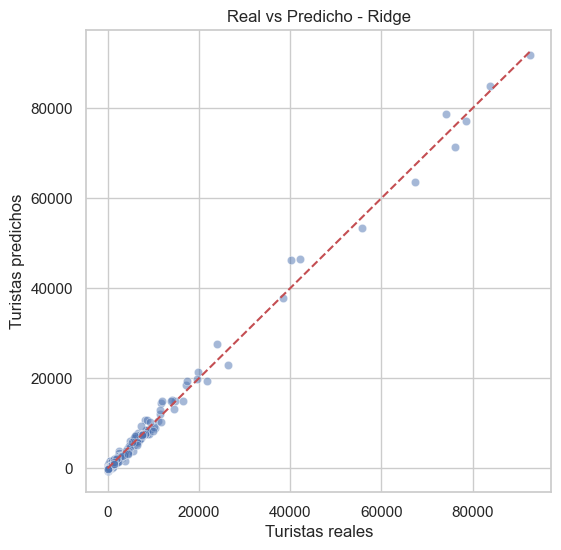

In [8]:
pred_best = mejor_modelo.predict(X_test)
comparacion = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": pred_best,
})

plt.figure(figsize=(6, 6))
sns.scatterplot(data=comparacion, x="Real", y="Predicho", alpha=0.5)
max_val = max(comparacion["Real"].max(), comparacion["Predicho"].max())
plt.plot([0, max_val], [0, max_val], "r--")
plt.title(f"Real vs Predicho - {mejor_modelo_nombre}")
plt.xlabel("Turistas reales")
plt.ylabel("Turistas predichos")
plt.show()

## 4) Validación Cruzada

In [9]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_cv = train_df[FEATURES]
y_cv = train_df[TARGET]

cv_resultados = []

for nombre, modelo in modelos.items():
    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", modelo),
        ]
    )

    mae_scores = -cross_val_score(
        pipe, X_cv, y_cv, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1
    )
    rmse_scores = np.sqrt(
        -cross_val_score(
            pipe, X_cv, y_cv, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1
        )
    )
    r2_scores = cross_val_score(pipe, X_cv, y_cv, cv=cv, scoring="r2", n_jobs=-1)

    cv_resultados.append({
        "Modelo": nombre,
        "CV_MAE_mean": mae_scores.mean(),
        "CV_MAE_std": mae_scores.std(),
        "CV_RMSE_mean": rmse_scores.mean(),
        "CV_RMSE_std": rmse_scores.std(),
        "CV_R2_mean": r2_scores.mean(),
        "CV_R2_std": r2_scores.std(),
    })

df_cv = pd.DataFrame(cv_resultados).sort_values("CV_RMSE_mean").reset_index(drop=True)
display(df_cv)

,Modelo,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std
0,Gradient Boosting Regressor,314.076002,14.637219,1060.327396,84.281548,0.982164,0.003270
1,Random Forest Regressor,292.766339,15.473009,1088.734829,134.831622,0.980888,0.005823
2,Ridge,371.824810,25.858403,1148.504886,252.291667,0.978309,0.009181
3,Linear Regression,372.507411,25.525180,1149.150116,252.975230,0.978282,0.009207


## 5) Predicción con Nuevos Registros

In [17]:
# Predicción interna por estado (para mantener la señal del modelo)
base_estado = (
    df_model.sort_values("Fecha")
    .groupby(["Pais", "Estado", "Tipo_Visitante"], as_index=False)
    .tail(1)
    .copy()
)

# Definimos un único horizonte de predicción para usuario final: próximo mes al último disponible
fecha_referencia = df_model["Fecha"].max()
fecha_objetivo = fecha_referencia + pd.DateOffset(months=1)
mes_objetivo = int(fecha_objetivo.month)
anio_objetivo = int(fecha_objetivo.year)

base_estado["Mes_Num"] = mes_objetivo
base_estado["Anio"] = anio_objetivo

# Ajuste simple para variables de rezago al proyectar un mes adelante
base_estado["lag_12"] = base_estado["lag_12"].fillna(base_estado["lag_1"])
base_estado["rolling_3_mean"] = (base_estado["rolling_3_mean"] * 2 + base_estado["lag_1"]) / 3

pred_estado = mejor_modelo.predict(base_estado[FEATURES])
pred_estado = np.round(pred_estado).astype(int)
pred_estado = np.clip(pred_estado, 0, None)

predicciones_detalle = base_estado[["Pais", "Estado", "Tipo_Visitante"]].copy()
predicciones_detalle["Anio"] = anio_objetivo
predicciones_detalle["Mes_Num"] = mes_objetivo
predicciones_detalle["Mes"] = MAPA_MESES_INV[mes_objetivo]
predicciones_detalle["Prediccion_Turistas"] = pred_estado

# Salida orientada a usuario final (sin Estado): mes + pais + tipo + numero de turistas
predicciones_usuario = (
    predicciones_detalle
    .groupby(["Anio", "Mes", "Pais", "Tipo_Visitante"], as_index=False)["Prediccion_Turistas"]
    .sum()
    .sort_values("Prediccion_Turistas", ascending=False)
    .reset_index(drop=True)
)

print(f"Predicción agregada para: {MAPA_MESES_INV[mes_objetivo].title()} {anio_objetivo}")
display(predicciones_usuario[["Mes", "Pais", "Tipo_Visitante", "Prediccion_Turistas"]].head(15))


def consultar_prediccion_usuario(mes: str, pais: str, tipo_visitante: str) -> str:
    mes = str(mes).strip().lower()
    pais = str(pais).strip().lower()
    tipo_visitante = str(tipo_visitante).strip().lower()

    filtro = predicciones_usuario[
        predicciones_usuario["Mes"].str.lower().eq(mes)
        & predicciones_usuario["Pais"].str.lower().eq(pais)
        & predicciones_usuario["Tipo_Visitante"].str.lower().eq(tipo_visitante)
    ]

    if filtro.empty:
        return f"No hay predicción para mes={mes}, país={pais}, tipo={tipo_visitante}."

    total = int(filtro.iloc[0]["Prediccion_Turistas"])
    return f"Predicción {mes.title()} {anio_objetivo} | {pais.title()} | {tipo_visitante.title()}: {total:,} turistas"


print(consultar_prediccion_usuario("marzo", "Estados Unidos", "Extranjero"))
print(consultar_prediccion_usuario("marzo", "Estados Unidos", "Dominicano"))
# print(consultar_prediccion_usuario("marzo", "Estados Unidos", "Extranjero"))
# print(consultar_prediccion_usuario("marzo", "Estados Unidos", "Extranjero"))

Predicción agregada para: Marzo 2026


,Mes,Pais,Tipo_Visitante,Prediccion_Turistas
0,marzo,Estados Unidos,Extranjero,259750
1,marzo,Canadá,Extranjero,164777
2,marzo,Estados Unidos,Dominicano,86435
3,marzo,Resto,Extranjero,84774
4,marzo,Argentina,Extranjero,42860
5,marzo,Colombia,Extranjero,20059
6,marzo,Francia,Extranjero,18670
7,marzo,Perú,Extranjero,14443
8,marzo,Chile,Extranjero,12962
9,marzo,Brasil,Extranjero,7851


Predicción Marzo 2026 | Estados Unidos | Extranjero: 259,750 turistas
Predicción Marzo 2026 | Estados Unidos | Dominicano: 86,435 turistas


## 6) Interpretación de Resultados

In [11]:
# Importancia de variables (Random Forest)
rf_pipe = pipelines_entrenados["Random Forest Regressor"]
rf_features = rf_pipe.named_steps["preprocessor"].get_feature_names_out()
rf_importancias = rf_pipe.named_steps["model"].feature_importances_

df_importancias = pd.DataFrame({
    "Feature": rf_features,
    "Importance": rf_importancias,
}).sort_values("Importance", ascending=False)

print("Top 12 variables más importantes (Random Forest):")
display(df_importancias.head(12))

# Coeficientes de Ridge (interpretación lineal)
ridge_pipe = pipelines_entrenados["Ridge"]
ridge_features = ridge_pipe.named_steps["preprocessor"].get_feature_names_out()
ridge_coef = ridge_pipe.named_steps["model"].coef_

df_coef = pd.DataFrame({
    "Feature": ridge_features,
    "Coef": ridge_coef,
    "Abs_Coef": np.abs(ridge_coef),
}).sort_values("Abs_Coef", ascending=False)

print("Top 12 coeficientes de mayor magnitud (Ridge):")
display(df_coef.head(12))

Top 12 variables más importantes (Random Forest):


,Feature,Importance
3,num__lag_12,0.882066
2,num__lag_1,0.092401
4,num__rolling_3_mean,0.019464
0,num__Mes_Num,0.001828
1,num__Anio,0.001118
147,cat__Estado_Ontario,0.000450
20,cat__Pais_Estados Unidos,0.000358
160,cat__Estado_Quebec,0.000351
11,cat__Pais_Canadá,0.000290
197,cat__Tipo_Visitante_Dominicano,0.000141


Top 12 coeficientes de mayor magnitud (Ridge):


,Feature,Coef,Abs_Coef
3,num__lag_12,6146.186602,6146.186602
2,num__lag_1,2464.717507,2464.717507
160,cat__Estado_Quebec,864.169556,864.169556
147,cat__Estado_Ontario,732.673593,732.673593
4,num__rolling_3_mean,-657.279951,657.279951
63,cat__Estado_Buenos Aires,518.958448,518.958448
153,cat__Estado_Pennsylvania,414.834303,414.834303
134,cat__Estado_New York,-388.832632,388.832632
75,cat__Estado_Cundinamarca,373.598832,373.598832
113,cat__Estado_Madrid,-360.834488,360.834488


In [12]:
mejor_test = df_resultados.iloc[0]
mejor_cv = df_cv.iloc[0]

print("=== RESUMEN PARA INFORME TÉCNICO ===")
print(f"1) Problemas de calidad: nulos en Turistas={df_raw['Turistas'].isna().sum()} y outliers IQR={outliers}.")
print("2) Preprocesamiento: imputación (mediana/moda), OneHotEncoder, StandardScaler, y features lag_1/lag_12/rolling_3_mean.")
print("3) Modelo con mejor test:")
print(f"   {mejor_test['Modelo']} | MAE={mejor_test['MAE']:.2f} | RMSE={mejor_test['RMSE']:.2f} | R2={mejor_test['R2']:.4f}")
print("4) Modelo más estable en CV (menor CV_RMSE_mean):")
print(f"   {mejor_cv['Modelo']} | CV_RMSE={mejor_cv['CV_RMSE_mean']:.2f} +/- {mejor_cv['CV_RMSE_std']:.2f} | CV_R2={mejor_cv['CV_R2_mean']:.4f}")
print("5) Predicción con nuevos registros: ver tabla de 'Prediccion_Turistas' en la sección anterior.")
print("6) Limitaciones: horizonte histórico corto (2022-2026), meses faltantes en 2026 y posible cambio estructural por país/estado.")

=== RESUMEN PARA INFORME TÉCNICO ===
1) Problemas de calidad: nulos en Turistas=3442 y outliers IQR=1829.
2) Preprocesamiento: imputación (mediana/moda), OneHotEncoder, StandardScaler, y features lag_1/lag_12/rolling_3_mean.
3) Modelo con mejor test:
   Ridge | MAE=407.43 | RMSE=729.84 | R2=0.9942
4) Modelo más estable en CV (menor CV_RMSE_mean):
   Gradient Boosting Regressor | CV_RMSE=1060.33 +/- 84.28 | CV_R2=0.9822
5) Predicción con nuevos registros: ver tabla de 'Prediccion_Turistas' en la sección anterior.
6) Limitaciones: horizonte histórico corto (2022-2026), meses faltantes en 2026 y posible cambio estructural por país/estado.
